In [1]:
import pandas as pd
import matplotlib.pyplot as plt

print("Libraries loaded successfully")

Libraries loaded successfully


In [4]:
import pandas as pd

df = pd.read_csv("nigeria_tasmax.csv")

df.head()

,state_code,state,scenario,period,tasmax_c
0,NGA.18265698,Abia,SSP1-1.9,2020-07,31.57
1,NGA.18265698,Abia,SSP2-4.5,2020-07,31.62
2,NGA.18265698,Abia,SSP3-7.0,2020-07,31.60
3,NGA.1822221,Abuja,SSP1-1.9,2020-07,32.89
4,NGA.1822221,Abuja,SSP2-4.5,2020-07,32.93


In [5]:
print("Number of rows:", len(df))
print("Number of states:", df["state"].nunique())
print("Scenarios:", df["scenario"].unique())
print("Periods:", df["period"].unique())

Number of rows: 111
Number of states: 37
Scenarios: ['SSP1-1.9' 'SSP2-4.5' 'SSP3-7.0']
Periods: ['2020-07']


In [6]:
df["tasmax_c"].describe()

count    111.000000
mean      32.496036
std        1.560795
min       29.420000
25%       31.350000
50%       32.620000
75%       33.435000
max       35.580000
Name: tasmax_c, dtype: float64

In [7]:
summary = (
    df.groupby("scenario")["tasmax_c"]
      .agg(["mean", "min", "max"])
      .round(2)
)

summary

,mean,min,max
scenario,,,
SSP1-1.9,32.48,29.42,35.55
SSP2-4.5,32.52,29.49,35.58
SSP3-7.0,32.48,29.44,35.53


In [8]:
df[["state", "scenario", "tasmax_c"]].head(15)

,state,scenario,tasmax_c
0,Abia,SSP1-1.9,31.57
1,Abia,SSP2-4.5,31.62
2,Abia,SSP3-7.0,31.60
3,Abuja,SSP1-1.9,32.89
4,Abuja,SSP2-4.5,32.93
5,Abuja,SSP3-7.0,32.87
6,Adamawa,SSP1-1.9,33.68
7,Adamawa,SSP2-4.5,33.72
8,Adamawa,SSP3-7.0,33.65
9,Akwa Ibom,SSP1-1.9,30.39


In [10]:
%pip install geopandas

   ---------------------------------------- 0.0/23.8 MB ? eta -:--:--
   ---------------------------------------- 0.3/23.8 MB ? eta -:--:--
   - -------------------------------------- 0.8/23.8 MB 2.4 MB/s eta 0:00:10
   --- ------------------------------------ 1.8/23.8 MB 3.3 MB/s eta 0:00:07
   ----- ---------------------------------- 3.1/23.8 MB 4.1 MB/s eta 0:00:05
   ------- -------------------------------- 4.5/23.8 MB 4.7 MB/s eta 0:00:05
   --------- ------------------------------ 5.5/23.8 MB 4.9 MB/s eta 0:00:04
   ------------ --------------------------- 7.6/23.8 MB 5.6 MB/s eta 0:00:03
   -------------- ------------------------- 8.9/23.8 MB 5.7 MB/s eta 0:00:03
   ---------------- ----------------------- 10.0/23.8 MB 5.9 MB/s eta 0:00:03
   --------------------- ------------------ 12.6/23.8 MB 6.3 MB/s eta 0:00:02
   ----------------------- ---------------- 14.2/23.8 MB 6.4 MB/s eta 0:00:02
   -------------------------- ------------- 15.7/23.8 MB 6.5 MB/s eta 0:00:02
   ------

In [12]:
import geopandas as gpd

print("GeoPandas is ready!")

GeoPandas is ready!


In [14]:
url = "https://raw.githubusercontent.com/deldersveld/topojson/master/countries/nigeria/nigeria-states.json"

import requests

response = requests.get(url)
print(response.status_code)

503


In [15]:
print("Data is ready.")
print(df.shape)

Data is ready.
(111, 5)


In [16]:
map_data = df.pivot(
    index="state",
    columns="scenario",
    values="tasmax_c"
).reset_index()

map_data.head()

scenario,state,SSP1-1.9,SSP2-4.5,SSP3-7.0
0,Abia,31.57,31.62,31.60
1,Abuja,32.89,32.93,32.87
2,Adamawa,33.68,33.72,33.65
3,Akwa Ibom,30.39,30.43,30.41
4,Anambra,32.14,32.18,32.15


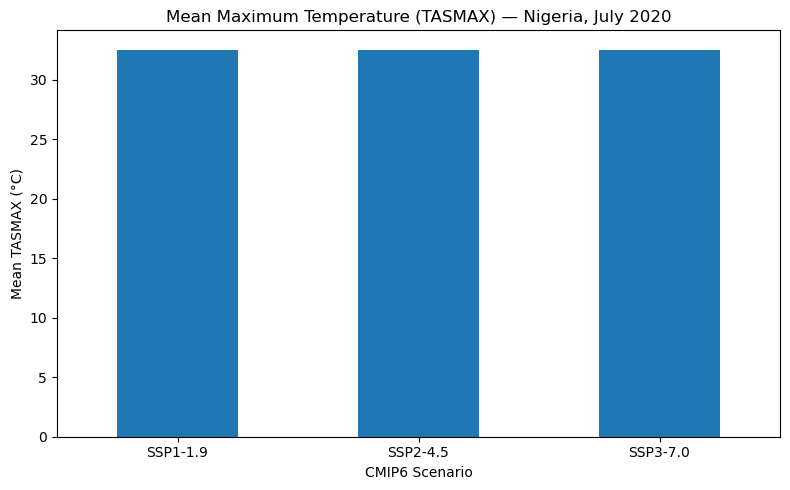

In [18]:
import matplotlib.pyplot as plt

df.groupby("scenario")["tasmax_c"].mean().plot(
    kind="bar",
    figsize=(8, 5)
)

plt.ylabel("Mean TASMAX (°C)")
plt.xlabel("CMIP6 Scenario")
plt.title("Mean Maximum Temperature (TASMAX) — Nigeria, July 2020")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [19]:
state_summary = (
    df.groupby("state")["tasmax_c"]
      .mean()
      .sort_values(ascending=False)
)

state_summary

state
Sokoto         35.553333
Borno          35.430000
Yobe           35.190000
Kebbi          34.940000
Jigawa         34.573333
Gombe          34.073333
Zamfara        33.913333
Niger          33.820000
Adamawa        33.683333
Kwara          33.430000
Nassarawa      33.163333
Katsina        33.163333
Benue          33.126667
Kano           33.060000
Bauchi         33.053333
Abuja          32.896667
Ebonyi         32.846667
Kogi           32.840000
Taraba         32.633333
Oyo            32.226667
Plateau        32.216667
Anambra        32.156667
Enugu          32.123333
Imo            31.673333
Abia           31.596667
Kaduna         31.473333
Edo            31.470000
Cross River    31.363333
Ogun           31.050000
Ekiti          30.963333
Osun           30.930000
Delta          30.876667
Ondo           30.710000
Rivers         30.450000
Akwa Ibom      30.410000
Bayelsa        29.823333
Lagos          29.450000
Name: tasmax_c, dtype: float64

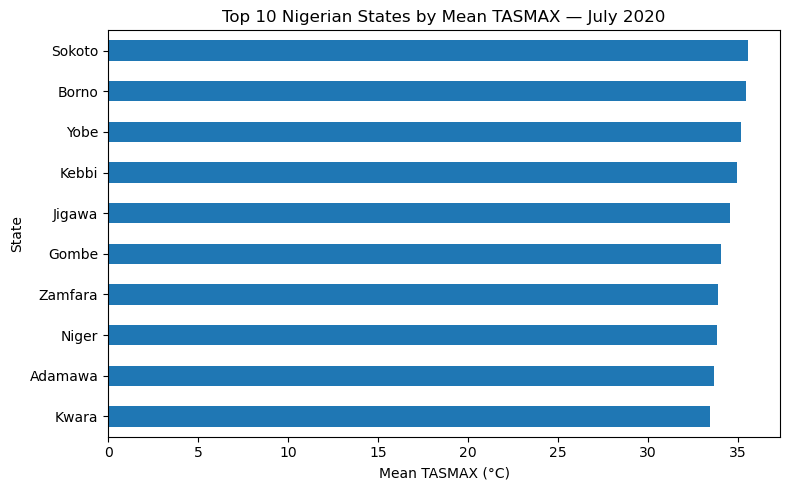

In [20]:
state_summary.head(10).sort_values().plot(
    kind="barh",
    figsize=(8, 5)
)

plt.xlabel("Mean TASMAX (°C)")
plt.ylabel("State")
plt.title("Top 10 Nigerian States by Mean TASMAX — July 2020")
plt.tight_layout()
plt.show()

In [21]:
scenario_state = (
    df.pivot(
        index="state",
        columns="scenario",
        values="tasmax_c"
    )
    .sort_values("SSP3-7.0", ascending=False)
)

scenario_state.head(10)

scenario,SSP1-1.9,SSP2-4.5,SSP3-7.0
state,,,
Sokoto,35.55,35.58,35.53
Borno,35.42,35.47,35.40
Yobe,35.18,35.22,35.17
Kebbi,34.93,34.97,34.92
Jigawa,34.57,34.59,34.56
Gombe,34.07,34.10,34.05
Zamfara,33.91,33.93,33.90
Niger,33.81,33.85,33.80
Adamawa,33.68,33.72,33.65


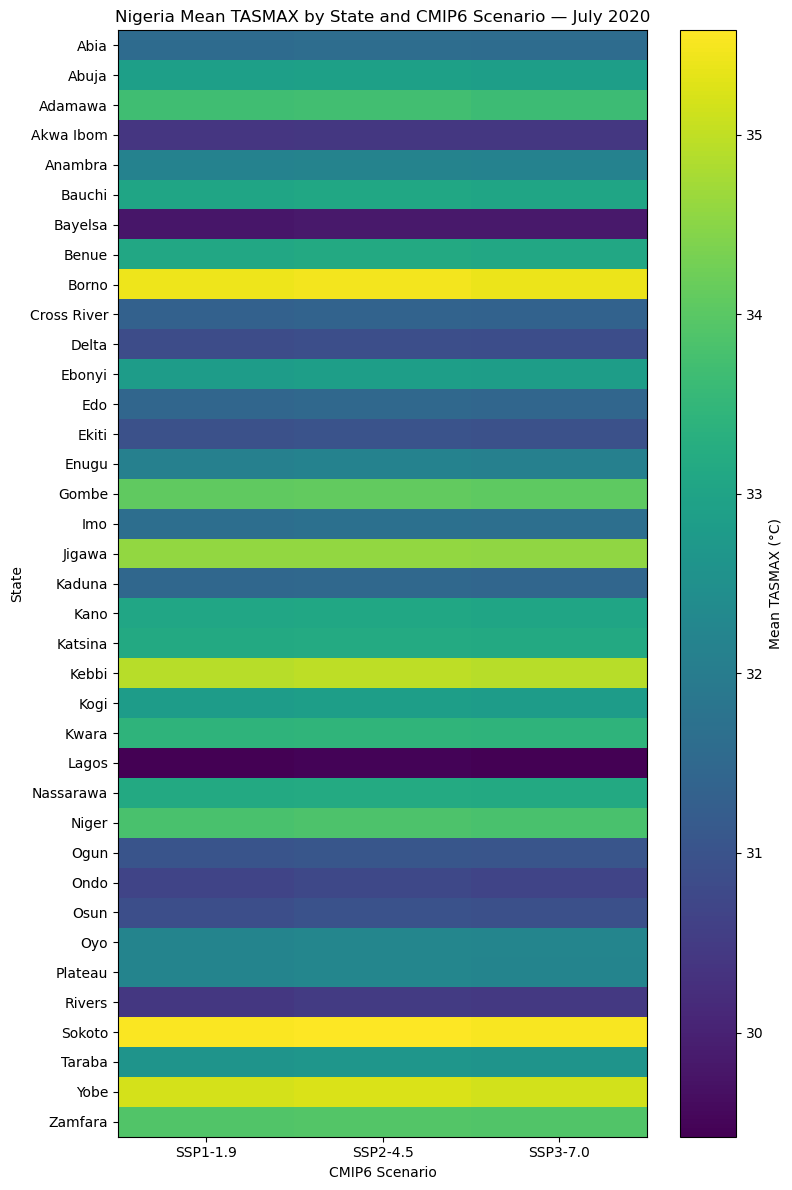

In [22]:
import matplotlib.pyplot as plt

heatmap_data = df.pivot(
    index="state",
    columns="scenario",
    values="tasmax_c"
)

plt.figure(figsize=(8, 12))

plt.imshow(heatmap_data, aspect="auto")

plt.colorbar(label="Mean TASMAX (°C)")

plt.xticks(
    range(len(heatmap_data.columns)),
    heatmap_data.columns
)

plt.yticks(
    range(len(heatmap_data.index)),
    heatmap_data.index
)

plt.xlabel("CMIP6 Scenario")
plt.ylabel("State")
plt.title("Nigeria Mean TASMAX by State and CMIP6 Scenario — July 2020")

plt.tight_layout()
plt.show()

In [26]:
# CMIP6 TASMAX Analysis — Nigeria

## Overview

This notebook explores CMIP6 projected mean maximum air temperature (TASMAX) across Nigerian states.

The dataset contains state-level mean TASMAX values for July 2020 under three CMIP6 scenarios:

- SSP1-1.9
- SSP2-4.5
- SSP3-7.0

## Data

The dataset contains:

- 37 Nigerian locations (36 states + FCT)
- 3 CMIP6 scenarios
- Mean TASMAX in degrees Celsius (C)
- Period: July 2020

## Analysis

The analysis includes:

1. Basic dataset inspection and validation
2. Summary statistics by CMIP6 scenario
3. Ranking of Nigerian states by mean TASMAX
4. Comparison of TASMAX across scenarios
5. State-by-scenario heatmap

## Key observation

For the July 2020 data available in this dataset, the average TASMAX values are very similar across the three scenarios. The main spatial variation is therefore between Nigerian states rather than between scenarios.

The overall mean TASMAX is approximately 32.5 C, with values ranging from approximately 29.4 C to 35.6 C.

## Important limitation

This dataset currently represents July 2020 only. It should **not** be described as a 2020–2039 time-period analysis unless additional years/months are added to the dataset.

The analysis therefore represents a snapshot of mean TASMAX for July 2020 and is intended as a preliminary demonstration of the CMIP6 climate-data workflow.

## Next steps

Future development of the project will include:

- State-level spatial TASMAX maps
- Additional years/months for the 2020–2039 period
- Scenario comparison through time
- Identification of high-temperature hotspots
- Integration of relevant DCP plant locations
- Publication as a reproducible GitHub climate-risk product

SyntaxError: invalid character '–' (U+2013) (1365898371.py, line 40)